# 1.	14-3-3 binding Proteins Show Distinct Properties in Biomolecular Condensates and Phase Separation

task 1: compiled a dataset of known 14-3-3 docking sites and proteins (Table 1), collect an independent dataset, which have not been seen by previous model. 

In [1]:
# download the dataset (bioinformatics_31_14_2276_s1.zip)used in 14-3-3-pre
# https://academic.oup.com/bioinformatics/article/31/14/2276/254687#supplementary-data
# bioinformatics_31_14_2276_s1.zip
import zipfile
import os

# Define the zip file name and the folder to extract to
zip_file_name = 'data/bioinformatics_31_14_2276_s1.zip'
extract_folder = 'data/bioinformatics_31_14_2276_s1'

# Check if the folder exists, if not, create it
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

# Open the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    # Extract all the contents into the specified folder
    zip_ref.extractall(extract_folder)

print(f'Extracted {zip_file_name} into {extract_folder}')

Extracted data/bioinformatics_31_14_2276_s1.zip into data/bioinformatics_31_14_2276_s1


In [2]:
# download the dataset (NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx) used in 14-3-3 finder
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10099770/#SM1
# save as NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx

In [3]:
# to establish a independent dataset, we will extract the data point in the dataset (20240518final_merge_data_with_high_1433pre_mapped_to_human.csv) but not 14-3-3 pred and 14-3-3 finder dataset
import pandas as pd
pred_dataset_name = 'data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx'
finder_dataset_name = "data/NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx"
curated_dataset_name = "data/20240518final_merge_data_with_high_1433pre_mapped_to_human.csv"

In [4]:
# the data in data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx have 4 tab, combine them into one
file_path = pred_dataset_name
excel_file = pd.ExcelFile(file_path)

# Let's get the sheet names
sheet_names = excel_file.sheet_names

# Create an empty list to hold dataframes
dfs = []

# Loop through the sheet names and read each sheet into a dataframe
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    # Optionally, you can add a column indicating the sheet name, useful for tracking the data source
    df['Source_Sheet'] = sheet
    dfs.append(df)

# Concatenate all the dataframes
pred_dataset_df = pd.concat(dfs, ignore_index=True)
pred_dataset_df = pred_dataset_df[pred_dataset_df['PMID'] != '*Likely NEG sites ']
pred_dataset_df = pred_dataset_df[["Uniprot ID","Site","Residue"]]
pred_dataset_df["Site"] = pred_dataset_df["Site"].astype(int)
pred_dataset_df.head(2)

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Uniprot ID,Site,Residue
0,P78314,225,S
1,P78314,278,S


In [5]:
# 14-3-3 finder dataset preprocess
finder_dataset_df = pd.read_excel(finder_dataset_name)
finder_dataset_df = finder_dataset_df[["Uniprot ID", 'Site',"Residue"]]
finder_dataset_df.head(2)

,Uniprot ID,Site,Residue
0,A7KAX9,1796,S
1,O00159,736,S


In [6]:
import re
previous_datset_df = pd.concat([pred_dataset_df, finder_dataset_df], ignore_index=True)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(str)

# Define the replacement function
def replace_value(value):
    matches = re.findall(r'\(([^)]+)\)', value)    
    if matches:
        return matches[0]  # Replace with the number within parentheses
    else:
        return value


# Apply the function to the 'Site' column
previous_datset_df['Site'] = previous_datset_df['Site'].apply(replace_value)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(int)

# remove duplicates
previous_datset_df = previous_datset_df.drop_duplicates(subset=["Uniprot ID", "Site"], keep='first')

previous_datset_df["uniqueID"] = (
    previous_datset_df["Uniprot ID"].str.strip() + "_" +
    previous_datset_df["Residue"].str.strip().str.upper() +
    previous_datset_df["Site"].astype(str).str.strip() +
    previous_datset_df["Residue"].str.strip().str.lower()
)

# put the uniqueID into a set
uniqueid_dict = set(previous_datset_df["uniqueID"])

has_duplicates = previous_datset_df["uniqueID"].duplicated().any()
print(f"Are there duplicates in column uniqueID? {has_duplicates}")

Are there duplicates in column uniqueID? False


In [7]:
# preprocess the curated dataset
curated_dataset_df = pd.read_csv(curated_dataset_name)
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)
curated_dataset_df = curated_dataset_df.drop_duplicates(subset=["uniqueID"], keep="first")

# save table 1 as the supplement for the paper
table1_df = curated_dataset_df[["human homology accession","human homology site without letter", "human Site and Mutation", "label", "PMID"]]
table1_df.to_csv("data/Table 1.csv", index=False)

In [8]:
independent_dataset_df = curated_dataset_df[~curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
independent_dataset_df["label"].value_counts()

label
0    182
1    181
Name: count, dtype: int64

In [9]:
used_dataset_df =  curated_dataset_df[curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
used_dataset_df["label"].value_counts()

label
0    309
1    276
Name: count, dtype: int64

In [10]:
# we have too much independent data here, some of the indepnedent data will also be used for training.

In [11]:
# check how many of the independent data are come from the mutation of a positive site sample
# those data should be exclude from the training dataset to avoid overfitting
# add more previous not see protein in the training dataset
# independent_dataset_df[independent_dataset_df['uniqueID'].str.contains('/')].head(2)

taks 2: In the curated dataset, we have observed that the proteins containing positive and negative samples largely overlap 

In [12]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df.head()

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511


In [13]:
# !conda install conda-forge::matplotlib-venn

Label 0 unique proteins: 153
Label 1 unique proteins: 288
Overlapping proteins: 142


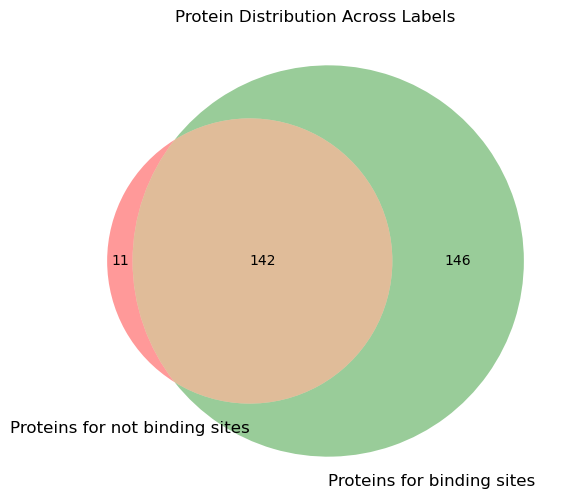

In [14]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd

def plot_protein_venn(df, protein_col='human homology accession', label_col='label'):
    # Get sets of proteins for each label
    label_0_proteins = set(df[df[label_col] == 0][protein_col])
    label_1_proteins = set(df[df[label_col] == 1][protein_col])
    
    # Create Venn diagram
    plt.figure(figsize=(10, 6))
    venn2([label_0_proteins, label_1_proteins], 
          set_labels=('Proteins for not binding sites', 'Proteins for binding sites'))
    plt.title('Protein Distribution Across Labels')
    
    # Display counts
    print(f"Label 0 unique proteins: {len(label_0_proteins)}")
    print(f"Label 1 unique proteins: {len(label_1_proteins)}")
    print(f"Overlapping proteins: {len(label_0_proteins.intersection(label_1_proteins))}")
    
    plt.show()
    
plot_protein_venn(curated_dataset_df, protein_col='human homology accession', label_col='label')

In [15]:
import pandas as pd

# Load the dataset
curated_dataset_df = pd.read_csv("data/Table 1.csv")

# Filter the dataset to include only positive labels
curated_dataset_df_positive = curated_dataset_df[curated_dataset_df["label"] == 1]

# Group by "human homology accession" and calculate the count of each unique protein ID
protein_counts = curated_dataset_df_positive.groupby("human homology accession").size().reset_index(name='count')

protein_counts["count"].value_counts()

count
1    166
2     88
3     24
4      7
5      3
Name: count, dtype: int64

task 3: we curated a dataset from BioGrid (ref), which collected all 14-3-3 binding proteins reported in the literature. 

In [ ]:
# 1.1 get all the human protein which interaction with 14-3-3

# download protein protein interaction dataset from Biogrid
# Read the tab-separated file into a DataFrame

file_path = "data/BIOGRID-ALL-4.4.237.mitab.zip"

biogrid = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')

# Display the DataFrame
biogrid.head(2)

In [ ]:
# select all the interaction happening between human proteins
biogrid = biogrid[(biogrid['Taxid Interactor A'] == "taxid:9606")&(biogrid['Taxid Interactor B'] == "taxid:9606")]
import pandas as pd
import re
def extract_and_clean_uniprot_id(text):
    # Regex pattern to match 'uniprot/swiss-prot:P45985'
    match = re.search(r'uniprot/swiss-prot:([\w\d]+)', text)
    return match.group(1) if match else None
# Apply the function to the DataFrame columns

biogrid['Uniprot ID A'] = biogrid['Alt IDs Interactor A'].apply(extract_and_clean_uniprot_id)
biogrid['Uniprot ID B'] = biogrid['Alt IDs Interactor B'].apply(extract_and_clean_uniprot_id)
biogrid_interactions = biogrid[['Uniprot ID A','Uniprot ID B']]
biogrid_interactions.head(2)

In [ ]:
Protins_1433 = ["P62258", "P27348", "Q04917", "P61981", "P31946", "P31947", "P63104"]
Protein_1433_interactome_df = biogrid_interactions[biogrid_interactions["Uniprot ID A"].isin(Protins_1433)]
Protein_1433_interactome = set(Protein_1433_interactome_df["Uniprot ID B"])
len(Protein_1433_interactome)

In [ ]:
# there are totally 1760 human protein interaction with human 14-3-3s

In [ ]:
# save the 1433_interactome as a dataset

task 4: Using Gene Ontology (GO) analysis, we discovered that these proteins are associated with several GO terms related to condensation, including non-membrane-bounded organelles 

In [ ]:
df = pd.read_csv("data/Table 1.csv")
df_1433 = df[df["label"]==1]
Protein_1433_interactome_known_motif = set(df_1433["human homology accession"]) 
len(Protein_1433_interactome_known_motif)

In [ ]:
# Gene Ontology (GO) analysis
# # Install gprofiler-official
# !pip install gprofiler-official

In [ ]:
from gprofiler import GProfiler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to transform p-values to -log10(p-value)
def transform_pvalues(df):
    df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
    return df

def go_analysis(uniprot_ids):
    # Initialize g:Profiler
    gp = GProfiler(return_dataframe=True)

    # Convert UniProt IDs to Gene Symbols (using g:Convert)
    converted_ids = gp.convert(organism='hsapiens', query=uniprot_ids, target_namespace='ENTREZGENE_ACC')

    # Extract the gene symbols
    gene_symbols = converted_ids['converted'].tolist()
#     print("Converted Gene Symbols:", gene_symbols)

    # Perform GO enrichment analysis using the converted gene symbols
    BP_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:BP'])
    MF_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:MF'])
    CC_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:CC'])

    # Display results
#     print(go_results.head())

    # Optional: Visualize the top 10 GO terms
    import matplotlib.pyplot as plt
    import seaborn as sns
    
#     print(BP_go_results)
    # Select top terms
    BP_top_go_terms = BP_go_results.head(20)
    MF_top_go_terms = MF_go_results.head(20)
    CC_top_go_terms = CC_go_results.head(20)

    # Transform p-values to -log10(p-value)
    BP_top_go_terms = transform_pvalues(BP_top_go_terms)
    MF_top_go_terms = transform_pvalues(MF_top_go_terms)
    CC_top_go_terms = transform_pvalues(CC_top_go_terms)

    # Combine data into a single DataFrame
    BP_top_go_terms['Category'] = 'Biological Process'
    MF_top_go_terms['Category'] = 'Molecular Function'
    CC_top_go_terms['Category'] = 'Cellular Component'

    combined_df = pd.concat([BP_top_go_terms, MF_top_go_terms, CC_top_go_terms])

    # Create a plot
    plt.figure(figsize=(14, 12))

    # Create a bar plot with custom width
    sns.barplot(
        data=combined_df,
        y='name',
        x='-log10(p-value)',
        hue='Category',
        palette={'Biological Process': 'skyblue', 'Molecular Function': 'lightgreen', 'Cellular Component': 'salmon'},
        dodge=False  # This ensures that bars are not split by hue
    )

    # Adjust bar width by setting the aspect ratio
    plt.gca().set_aspect('auto', adjustable='box')

    # Title and labels
    plt.title('Top GO Terms by Category')
    plt.xlabel('-log10(p-value)')
    plt.ylabel('GO Term')

#     # Invert y-axis
#     plt.gca().invert_yaxis()

    # Add a legend
    plt.legend(title='GO Category')

    # Show the plot
    plt.tight_layout()
    plt.show()

In [ ]:
go_analysis(list(Protein_1433_interactome))

In [ ]:
go_analysis(list(Protein_1433_interactome_known_motif))

task 5: We also performed KEGG analysis of 14-3-3 binding proteins and BioGrid 14-3-3 binding proteins to support the above analysis. 

In [ ]:
# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Perform enrichment for your own proteins and BioGrid proteins separately
results_my_proteins = gp.profile(
    organism='hsapiens',  # Homo sapiens. Change based on your organism.
    query=list(Protein_1433_interactome_known_motif),
    sources=['KEGG'])  # Specify to use KEGG pathways

# Ensure the results are DataFrame
if not isinstance(results_my_proteins, pd.DataFrame):
    raise TypeError('Expected the results of my_proteins to be a DataFrame.')

results_biogrid_proteins = gp.profile(
    organism='hsapiens',
    query=list(Protein_1433_interactome),
    sources=['KEGG'])

# Ensure the results are DataFrame
if not isinstance(results_biogrid_proteins, pd.DataFrame):
    raise TypeError('Expected the results of biogrid_proteins to be a DataFrame.')
    

# Function to convert list columns to strings
def convert_list_columns_to_string(df, columns):
    for col in columns:
        if col in df.columns and df[col].apply(lambda x: isinstance(x, list)).any():
            df[col] = df[col].apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else x)
    return df

# Columns to convert
columns_to_convert = ['native', 'parents']

# Convert list columns to strings in both DataFrames
results_my_proteins = convert_list_columns_to_string(results_my_proteins, columns_to_convert)
results_biogrid_proteins = convert_list_columns_to_string(results_biogrid_proteins, columns_to_convert)

In [ ]:
# Select top pathways based on adjusted p-value
top_my_proteins = results_my_proteins.sort_values(by='p_value').head(50)
top_biogrid_proteins = results_biogrid_proteins.sort_values(by='p_value').head(50)

# Plot the results for my_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_my_proteins['name'], -np.log10(top_my_proteins['p_value']), color='skyblue')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein with known motif)')
plt.gca().invert_yaxis()
plt.show()

# Plot the results for biogrid_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_biogrid_proteins['name'], -np.log10(top_biogrid_proteins['p_value']), color='orange')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# common pathway in 14-3-3 binding and 14-3-3 binding with known motif dataset
set(top_my_proteins['name'])&set(top_biogrid_proteins['name'])

task 6/7: 

## Analysis of Protein Condensation Potential and Phase Separation Properties

taks 8: download the predicted condensation score from Picnic(ref), DeePhase(ref), and PhaSePred(ref) 

In [ ]:
# download picnic data from https://picnic.cd-code.org/download/
# get the picnic value for each unique id
df_picnic = pd.read_csv('data/PICNIC-9606-data.csv')
df_picnic.head()

In [ ]:
# download DeePhase dataset
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'https://github.com/kadiliissaar/DeePhase/raw/main/Paper_code/Predictions/Swissprot/all_predictions.csv'

# # Define the filename and the path to save it
# filename = 'all_predictions.csv'
# save_path = os.path.join('data', filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

# Read the CSV file into a DataFrame
df_DeePhase = pd.read_csv('data/all_predictions.csv')

# Display the first few rows of the DataFrame
df_DeePhase.head()

In [ ]:
# PhaSePred
# ### download the dataset    
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'http://predict.phasep.pro/static/phasepred/database/human_reviewed.zip'

# # Define the filename and the path to save it
# zip_filename = 'human_reviewed.zip'
# save_path = os.path.join('data', zip_filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

In [ ]:
# human_reviewed.zip is a json file
import zipfile
import json
import pandas as pd
import os

# Specify the path to your zip file and the output directory
zip_file_path = 'data/human_reviewed.zip'

import pandas as pd
import json
from collections import defaultdict

def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def process_data(data):
    flattened_data = defaultdict(dict)
    
    for key, value in data.items():
        flat = flatten_dict(value)
        for k, v in flat.items():
            flattened_data[k][key] = v
    
    return pd.DataFrame(flattened_data)


# Define the output directory (can be the same directory as the zip file or any other)
output_directory = os.path.splitext(zip_file_path)[0]  # This will remove the .zip extension

#
print(output_directory)

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_directory)

# Read JSON file
json_file_path = os.path.join(output_directory, 'human_reviewed.json')  # adjust according to your actual file name

with open(json_file_path, 'r') as file:
    data = json.load(file)

# Process the data and create DataFrame
df_PhaSePred = process_data(data)

# Display the first few rows of the DataFrame
df_PhaSePred.head()

In [ ]:
df_PhaSePred.columns

In [ ]:
score_columns = ['uniprot_id','Sequence',
                 'catGRANULE_single','PLAAC_NLLR',
       'PScore_single', 
       'ESpritz-DisProt_single',
       'Hydropathy_single',
       'DeepCoil_single',
       'SEG_single',
       'Charged residue_FCR', 'Phos_single','PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea',
       'PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
       'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
       'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

df_PhaSePred['uniprot_id'] = df_PhaSePred.index

df_PhaSePred = df_PhaSePred[score_columns]

task 9: predict the condensation propensity of 14-3-3 binding proteins and compared with entire proteome condensation propensities. 
task 10: comparison of the condensation propensity scores of proteins in BioGrid dataset with proteins in the human proteome 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def distribution_go(gene_list, listname, df, score, ID):
    # Filter scores for the specific list of genes
    df_list_genes = df[df[ID].isin(gene_list)]
    
    # Create a figure with a specific style
    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")
    
    # Plot the score distribution for the entire gene set
    sns.histplot(df[score], color='#FFA07A', label='Whole Human Proteome', 
                 kde=True, bins=40, alpha=0.6, stat='density')
    
    # Plot the score distribution for the specific list of genes
    sns.histplot(df_list_genes[score], color='#4682B4', label=listname, 
                 kde=True, bins=40, stat='density')
    
    # Title and labels with improved fonts
    plt.title(f'Score Distribution: {listname} vs Whole Human Proteome', 
              fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(score, fontsize=14, fontweight='bold')
    plt.ylabel('Density', fontsize=14, fontweight='bold')
    
    # Improve tick labels
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add a legend with improved appearance
    plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)
    
    # Add a text box with statistics
    stats_text = f"{listname} stats:\nMean: {df_list_genes[score].mean():.2f}\nMedian: {df_list_genes[score].median():.2f}"
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Improve layout and display
    plt.tight_layout()
    plt.show()

In [ ]:
# picnic score
# two score using here: Picnic socre and picnic go score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind",df_picnic, "PICNIC score", 'Uniprot ID')

In [ ]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC GO score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_picnic, "PICNIC GO score", 'Uniprot ID')

In [ ]:
# deephase score
# two score using here: prediction_phys_multi socre and prediction_w2v_multi score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')

In [ ]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')

In [ ]:
# PhaSePred score
# a list score using here
phasepred_score_columns = ['PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea','PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
       'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
       'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

In [ ]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

task 11: we further compared phase separation-related physicochemical properties between the entire human proteome and 14-3-3 binding proteins, including FCR, IDR, LCR, catGRANULE, PLAAC, Pscore, Hydropathy, DeepCoil , SEG, Charged Residue, Phos and protein length  

In [ ]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column not in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

In [ ]:
# calculate the distribution of protein length of 14-3-3 binding protein

# write a code to iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# save into a csv file, for each uniprot id, save the length of the protein

import pandas as pd
from Bio import SeqIO

def calculate_protein_lengths(fasta_file, output_csv):
    data = []
    
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        if '|' in record.id:
            uniprot_id = record.id.split('|')[1]
        else:
            uniprot_id = record.id
        protein_length = len(record.seq)
        
        # Append the data to the list
        data.append([uniprot_id, protein_length])
    
    # Create a DataFrame from the list
    df = pd.DataFrame(data, columns=['UniProt ID', 'Protein Length'])
    
    # Save the DataFrame to a CSV file
    df.to_csv(output_csv, index=False)

# Define the input FASTA file and output CSV file
fasta_file = 'data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta'
output_csv = 'data/protein_lengths.csv'

# Call the function
calculate_protein_lengths(fasta_file, output_csv)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_length_distribution(uniprot_ids, protein_lengths_csv):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter out proteins with length 10 or less
    df = df[(df['Protein Length'] > 100)&(df['Protein Length'] < 5000)]
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_df = df[df['UniProt ID'].isin(uniprot_ids)]

    # Print the shortest and longest protein length in the whole dataset
    shortest_protein_length_whole = df['Protein Length'].min()
    longest_protein_length_whole = df['Protein Length'].max()
    print(f"Shortest protein length in the whole dataset: {shortest_protein_length_whole}")
    print(f"Longest protein length in the whole dataset: {longest_protein_length_whole}")

    # Print the shortest and longest protein length in the filtered dataset
    if not filtered_df.empty:
        shortest_protein_length_filtered = filtered_df['Protein Length'].min()
        longest_protein_length_filtered = filtered_df['Protein Length'].max()
        print(f"Shortest protein length in the filtered dataset: {shortest_protein_length_filtered}")
        print(f"Longest protein length in the filtered dataset: {longest_protein_length_filtered}")
        print(f"There are {len(filtered_df)} proteins in the dataset")
    else:
        print("No proteins found in the filtered dataset with length > 100.")
    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the specified proteins' lengths
    sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)
    
    # Add titles and labels
    plt.title('Protein Length Distribution Comparison')
    plt.xlabel('Protein Length')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

# Define the path to the protein lengths CSV file
protein_lengths_csv = 'data/protein_lengths.csv'

In [ ]:
compare_protein_length_distribution(Protein_1433_interactome_known_motif, protein_lengths_csv)
compare_protein_length_distribution(Protein_1433_interactome, protein_lengths_csv)

## PLM for condensation

task 12: employed protein language models ESM2 to extract the protein level embeddings for each protein in the human proteome

task 13: download the known condensation proteins dataset, we annotated the embeddings for known condensation proteins dataset (ref) from XXX experimentally validated PS proteins from PhaSepDB, LLPSDB, and PhaSePro

In [ ]:
# PhaSepDB
# http://db.phasep.pro/

In [ ]:
# LLPSDB
# http://www.bio-comp.org.cn/llpsdb/home.html

In [ ]:
# PhaSePro
# https://phasepro.elte.hu/

task 14: protein level embeddings for each protein in the human proteome clustering using UMAP to visualize protein-wide sequence characteristics, mapping 14-3-3 binding proteins and also mapping known condensation proteins

# 2	Intrinsically Disordered Regions Define the Context of 14-3-3 Binding Sites

2.1	Characterization of IDR Properties Around Binding Sites

task 14: predict IDR score of 14-3-3 binding sites using IUPred2A

In [ ]:
# https://iupred2a.elte.hu/
# download IUPred2A package and put into src/files folder 

In [ ]:
# uniprot download all the human reviewed protein sequence uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# https://www.uniprot.org/uniprotkb?query=reviewed%3Atrue&facets=model_organism%3A9606

In [ ]:
# write a code to iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# import iupred2a_lib 
# Predict using 'iupred2a_lib.iupred(sequence)'. Using the optional arg 'mode' it can be selected whether to predict long or short disorder. 
# iterate the fasta file, for each sequence, then predict it with iupred2a using 'iupred2a_lib.iupred(sequence)'
# predict anchor2 using (iupred2a_lib.anchor2(sequence) ) 
# save the each prediction result (iupred and anchor score) as a csv file, using uniprotid as the csv file name

In [ ]:
# !pip install biopython

In [ ]:
fasta_file = "data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta"
if not os.path.isfile(fasta_file):
    print(f"FASTA file '{fasta_file}' not found.")
    sys.exit(1)

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import src.files.iupred2a.iupred2a_lib as iupred2a_lib
from Bio import SeqIO

def process_sequence(uniprot_id, sequence, iupred_type, path, anchor):
    try:
        # Create the directory if it doesn't exist
        if not os.path.exists(path):
            os.makedirs(path)
        # Predict disorder using iupred2a_lib
        iupred_scores = iupred2a_lib.iupred(sequence, iupred_type)[0]

        # Predict anchor regions using iupred2a_lib if anchor is enabled
        anchor_scores = iupred2a_lib.anchor2(sequence)[0] if anchor else [None] * len(sequence)

        # Prepare the data for saving into a CSV file
        data = {
            "position": list(range(1, len(sequence) + 1)),
            "amino_acid": list(sequence),
            "iupred_score": iupred_scores,
            "anchor_score": anchor_scores,
        }

        # Create a DataFrame from the data
        df = pd.DataFrame(data)

        # Save the DataFrame to a CSV file named by the UniProt ID
        csv_filename = os.path.join(path, f"{uniprot_id}.csv")
        df.to_csv(csv_filename, index=False)
        print(f"Results saved for {uniprot_id} in {csv_filename}")
    except ImportError:
        sys.exit("ERROR: The import of iupred2a_lib failed! Most likely the PYTHONPATH has not been set correctly according to the README file.")


def human_proteome_disorder_cal(fasta_file):
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split('|')[1] if '|' in record.id else record.id
        sequence = str(record.seq)
        process_sequence(uniprot_id, sequence, "long", "data/human_proteome_discorder_anchor_score", 1)

In [ ]:
# human_proteome_disorder_cal(fasta_file)

task 15: figure we confirm that 14-3-3 binding sites are predicted to have higher IDR score than all s/t sites (Figure 2A)

In [ ]:
# # aggregate the calculated IDR and anchor score for all the S/T sites in the human proteome
# import pandas as pd
# import os

# def collect_st_amino_acids(folder_path):
#     # Initialize an empty DataFrame to hold the collected data
#     collected_data = pd.DataFrame()

#     # Iterate through each file in the folder
#     for filename in os.listdir(folder_path):
#         if filename.endswith('.csv'):
#             file_path = os.path.join(folder_path, filename)
#             df = pd.read_csv(file_path)
#             # Filter the DataFrame for rows where amino_acid is 'S' or 'T'
#             filtered_df = df[df['amino_acid'].isin(['S', 'T'])]

#             filename_pre = filename.split('.')[0]
#             # Rename the index to match the format filename_amino_acid_position
#             filtered_df.index = [f"{filename_pre}_{row['amino_acid']}_{row['position']}" for _, row in filtered_df.iterrows()]

#             # Append the filtered data to the collected_data DataFrame
#             collected_data = pd.concat([collected_data, filtered_df])

#     return collected_data

# # Define the folder path
# folder_path = 'data/human_proteome_discorder_anchor_score'

# # Collect the data
# st_amino_acids_df = collect_st_amino_acids(folder_path)

# # Print the collected DataFrame
# # print(st_amino_acids_df)

# # Optionally, save the collected DataFrame to a CSV file
# st_amino_acids_df.to_csv('data/collected_st_amino_acids_idrscore_anchorscore.csv')

In [ ]:
# download phosphorylation dataset from phosphorysite
# name as Phosphorylation_site_dataset.xlsx
def process_mod_rsd(mod_rsd):
    """
    Process the MOD_RSD value to replace a pattern like S119-p with S_119.
    
    Parameters:
    mod_rsd (str): The original MOD_RSD value.
    
    Returns:
    str: The processed MOD_RSD value.
    """
    if '-' in mod_rsd:
        parts = mod_rsd.split('-')
        return f"{parts[0][0]}_{parts[0][1:]}"
    return mod_rsd


def collect_human_sites(df):
    """
    Collects all human dataset entries from the provided DataFrame where the 8th position letter 
    in the SITE_+/-7_AA column is lowercase 's' or 't'. Each row in the returned DataFrame is 
    named using the format ACC_ID_MOD_RSD with processed MOD_RSD.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    human_df = df[df['ORGANISM'] == 'human']

    # Further filter the DataFrame where the 8th position letter in the SITE_+/-7_AA column is lowercase 's' or 't'
    filtered_human_df = human_df[human_df['SITE_+/-7_AA'].str[7].isin(['s', 't'])]

    # Process the MOD_RSD values
    filtered_human_df['MOD_RSD'] = filtered_human_df['MOD_RSD'].apply(process_mod_rsd)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_human_df.index = filtered_human_df.apply(lambda row: f"{row['ACC_ID']}_{row['MOD_RSD']}", axis=1)

    return filtered_human_df

phosphodata_path = "data/Phosphorylation_site_dataset.xlsx"

df = pd.read_excel(phosphodata_path, skiprows=3)

# Apply the function
filtered_human_df = collect_human_sites(df)

# # Print the filtered DataFrame
# print(filtered_human_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_human_df.to_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')

In [ ]:
filtered_human_df = pd.read_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')
konwn_human_phosphorylated_site = set(filtered_human_df["Unnamed: 0"])
len(konwn_human_phosphorylated_site)

In [ ]:
# preprocess the collected 14-3-3 site into a uniprot_aminoacid_postion index

def process_string(value):
    # Split the value by '/' to handle scenarios with multiple modifications
    parts = value.split('/')
    for part in parts:
        # Check if the first and last characters of the part match the criteria
        if part[0].isupper() and part[-1].islower() and part[0].upper() == part[-1].upper():
            return f"{part[0].upper()}_{part[1:-1]}"
    
    # If none of the parts match the criteria, return None or handle accordingly
    return None


def collect_1433_sites(df):
    """
    Collects 14-3-3 dataset entries from the provided DataFrame. Each row in the returned DataFrame is 
    named using the format ACC_ID with amino acid and position.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    filtered_df = df[df['label'] == 1]

    # Process the MOD_RSD values
    filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_df.index = filtered_df.apply(lambda row: f"{row['human homology accession']}_{row['human Site and Mutation']}", axis=1)

    return filtered_df

phosphodata_path = "data/Table 1.csv"

df = pd.read_csv(phosphodata_path)

# Apply the function
filtered_1433_df = collect_1433_sites(df)

# # Print the filtered DataFrame
# print(filtered_1433_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_1433_df.to_csv('data/1433_phosphorylated_site.csv')

In [ ]:
filtered_1433_df = pd.read_csv('data/1433_phosphorylated_site.csv')
konwn_1433_site = set(filtered_1433_df["Unnamed: 0"])
len(konwn_1433_site)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_feature_distribution(uniprot_ids_1433, uniprot_ids_known_phospho, protein_lengths_csv, columnname):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_1433_df = df[df["Unnamed: 0"].isin(uniprot_ids_1433)]
    filtered_known_phospho_df = df[df["Unnamed: 0"].isin(uniprot_ids_known_phospho)]    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the 1433 site
    sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)

    # Plot the distribution of the phospho site
    sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)
    
    # Add titles and labels
    plt.title(f'{columnname} Distribution Comparison')
    plt.xlabel(f'{columnname}')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

In [ ]:
st_idrscore_anchorscore_path = 'data/collected_st_amino_acids_idrscore_anchorscore.csv'
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "iupred_score")
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

2.2 Analysis of IDR Compactness and Flexibility

task 16: We used XX (ref) to extract the 14-3-3 binding protein IDR properties and compare it with the all other human IDRs.
task 17: We found that 14-3-3 binding IDR have higher XX and lower XX (Figure 2B).We compared the v of IDRs containing 14-3-3 binding sites with all IDRs in humans, and found that 14-3-3 binding sites preferentially located in relatively compact IDRs with lower ν value (Figure 2C).

In [ ]:
## download the IDRome dataset from
# https://github.com/KULL-Centre/_2023_Tesei_IDRome/blob/main/IDRome_DB.csv

In [ ]:
df_1433 = pd.read_csv("data/Table 1.csv")
df_1433
# select positive human sample to see the distribution
df_pos_human = df_1433[(df_1433["label"] == 1)]
df_pos_human

In [ ]:
df_idr = pd.read_csv("data/IDRome_DB.csv")
df_idr

In [ ]:
df_idr["start_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[1]))
df_idr["end_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[2]))

In [ ]:
uniprot_set = set(df_pos_human["human homology accession"])
mask_uniprot = df_idr["UniProt_ID"].isin(uniprot_set)
df_idr_uniprot = df_idr.loc[mask_uniprot]

In [ ]:
df_idr_uniprot_position = pd.DataFrame()

In [ ]:
for index, row in df_idr_uniprot.iterrows():
    uniprot_id = row["UniProt_ID"]
    start = row["start_site"]
    end = row["end_site"]
    df_filter = df_pos_human[df_pos_human["human homology accession"] == uniprot_id]
    for i, r in df_filter.iterrows():
        position = int(r["human homology site without letter"])
        if position >= start and position <= end:
            df_tmp = row.to_frame().T
            df_tmp["position"] = position
            # print(df_tmp.columns)
            if len(df_idr_uniprot_position)<1:
                df_idr_uniprot_position = df_tmp
            else:
                df_idr_uniprot_position = pd.concat([df_idr_uniprot_position, df_tmp], join="inner", axis=0, ignore_index=True)

df_idr_uniprot_position = df_idr_uniprot_position.drop_duplicates()
df_idr_uniprot_position

In [ ]:
feature = df_idr_uniprot_position.columns
feature
feature = feature.drop(['seq_name', 'UniProt_ID', 'start_site', 'end_site', 'position','N',"fasta", "is_btw_folded", "is_nterm",	"is_cterm",	"is_idp", "first", "last",	"N_FL",	"protein_name",	"gene_name"])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot(column):
    bins=20
    df1_name = "1433_core"
    df2_name = "Whole Human IDR"
    df1 = df_idr_uniprot_position
    df2 = df_idr

    # Set the style for the plot
    plt.style.use('seaborn')
    
    # Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot the histograms
    sns.histplot(data=df1, x=column, bins=bins, alpha=0.6, label=df1_name, kde=True, ax=ax, stat='density', color='#FFA07A',)
    sns.histplot(data=df2, x=column, bins=bins, alpha=0.6, label=df2_name, kde=True, ax=ax, stat='density', color='#4682B4')
    
    # Customize the plot
    ax.set_xlabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {column.capitalize()} in {df1_name} and {df2_name}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    # Add a grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the tick labels
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Add a text box with summary statistics
    stats_text = f"Summary Statistics:\n\n{df1_name}:\nMean: {df1[column].mean():.2f}\nMedian: {df1[column].median():.2f}\n\n{df2_name}:\nMean: {df2[column].mean():.2f}\nMedian: {df2[column].median():.2f}"
    plt.text(0.2, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

In [ ]:
for column in feature:
    plot(column)

In [ ]:
from scipy.stats import ks_2samp

def ks_test(column):
    # Perform Kolmogorov-Smirnov test
    statistic, p_value = ks_2samp(df_idr_uniprot_position[column], df_idr[column])
    
    # Interpret the result
    alpha = 0.05  # significance level
    print(f"KS statistic: {statistic}")
    print(f"P-value: {p_value}")
    if p_value < alpha:
        pass
        # print(f"The distributions are significantly different in column: {column}.")
    else:
        # pass
        print(f"No significant difference found between the distributions in column: {column}.")

for column in feature:
    ks_test(column)

task 18: employed protein language models ESM2 to extract the IDR level embeddings for each protein in the human proteome

task 19: We then performed clustering using UMAP to visualize protein-wide sequence characteristics (Figure 2D). By plotting the 14-3-3 binding proteins on the UMAP

# 3	Domain and motif-level analysis Captures Higher-Order Features

task 20: DisoFLAG for prediction

In [ ]:
# 需要服务器处理数据

task 21: DisoFLAG for prediction compare 14-3-3 binding site with whole human protemo

task 24: ANCHOR2 for prediction compare 14-3-3 binding site with whole human protemo through IUPred2A web

In [ ]:
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

task 25: we analysis the of sequence composition of 14-3-3 binding site.using window of various lengths, a window size of 51 (n=25) can maximize the performance in the prediction of aforementioned PTM sites

task 26: We therefore also extra the related feature using this domain size. ( 这里试试sequence-based features, physic-
ochemical property-based features and spatial mapping
information-based features,看irice的文章)

task 27: Phospholingo predicted score download, we found 14-3-3 binding sites have higher phosphorylation ability compared with both all the known phosphorylation site and all S or T in the proteome.

task 28: predict all the resident embedding of human proteome using PTM-mamba 

In [ ]:
#需要服务器

task 29: We first extract resident level of embedding in 15 aa and 100 aa of the 14-3-3 binding motif to represent the motif and domain level information, and performed clustering using UMAP to visualize characteristics of them compared with the embedding of all the other phosphorylated motif and domains. 

task 30: We also extract the residue embedding of 14-3-3 binding site and compare it with all S or T in the proteome and found that XXX (Figure 3B).

## 4.1	Positive data augmentation strategy: 

task 31: By analysis the 14-3-3 protein homology in evolution tree, we found that 14-3-3 is quite conservative until XX animal (Figure X). 

task 32: Utilizing this approach, we selected 5 different species (XX,XX) where the 14-3-3 protein sequences are conserved. To ensure adequate diversity, we also included different isoforms from these species. (sampling from uniref90?, then make sure by MSA, the sequence have a similary 14-3-3 sites)

In [ ]:
# 选1.uniref_90 2. aligment 3. at the positive have the same motif （比如 rxxs or rxxt） 4.blast similary 大致相同， 5. 在特定的种群列表里面 6。 距离最远的4个

In [ ]:
# 原始数据中有的蛋白上有5-1个位点，增强的数据应该把同源蛋白的数量填充到最多五个， 比如如果某个蛋白上有2个位点，那么我们只增强三个位点，使总蛋白数是5

In [ ]:
# 增强的数据位点，在用以前的predictor测试一下，保证增强数据在他们的短距离的predictor中是推荐的位点

In [ ]:
import subprocess
from Bio import AlignIO

def run_clustal_omega(in_file, out_file):
    # Running clustal omega using subprocess
    result = subprocess.run(
        ["clustalo", "-i", in_file, "-o", out_file, "--force", "--verbose"],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print("Error running Clustal Omega:")
        print(result.stderr)
        raise RuntimeError(f"Clustal Omega failed with return code {result.returncode}")

def check_motif_in_alignment(alignment_file, position, motif):
    alignment = AlignIO.read(alignment_file, "fasta")
    for record in alignment:
        sequence = str(record.seq)
        if sequence[position:position+len(motif)] != motif:
            print(f"Motif not found at specified position in sequence {record.id}")
            return False
    return True

# Input sequences in FASTA format
input_sequences = """
>seq1
ACGTACGTACGT
>seq2
ACGTACGACGT
>seq3
CGTACGTACGT
"""

with open("input.fasta", "w") as file:
    file.write(input_sequences)

# Run Clustal Omega to align sequences
run_clustal_omega("input.fasta", "aligned.fasta")

# Specify the position and motif
position = 2
motif = "GTAC"

# Check for the motif at the specified position
if check_motif_in_alignment("aligned.fasta", position, motif):
    print("Motif found at the specified position in all sequences.")
else:
    print("Motif not found in all sequences at the specified position.")

## 4.2	Negative data sampling strategy

task 33: we propose a negative data sampling strategy to augment the negative data. We first calculate the protein condensation,  IDR and phosphorylation feature（我到底应不应该用condensation 做负采样啊用multiple scale feature 做负采样，也许可以用IDR feature， 或者用embedding做负采样）score using human proteome, then bin and draw the distribution of those multiple scale features. When compare whole proteome distribution with the distribution of 14-3-3 binding proteins, we could see indeed the dataset we have is biased (Figure 4A). (Add some details about the distribution looks like).

task 34: we sampled data points from all the S and T site from human proteome to make the negative sample distribution close to the whole human proteome distribution. We exclude sampling from protein which have been reported interaction with 14-3-3, and exclude the site with high score site predicted using previous 14-3-3 predictor. 

task 35: Then, to reduce the sequence redundancy of proteins and avoid model overfitting, the CD-HIT program was used with the sequence identity threshold of 30%. After sample, we could see the distribution of condensation, IDR, phosphorylation now follow the same distribution of the whole protein and there is no significant different when tested by XX test

## 4.3	Feature selection 

task 36: modeling direct from only PLM embedding, we first compare using embeddings from either ESM2 or PTM-mamba to represent the whole protein or the residue embeddings, 

task 37: Then we tested modeling from multi-scale biology features plus onehot encoding for the -7 to +7 motif, the result show that multi-scale biology features also can be used to predict the 14-3-3 binding when compare with only use onehot encoded motif feature. 

task 38: We then test using both PLM and biology features, the results show that using both PLM and biology features shows improved results compared with using only PLM or multi-scale biology features. 

task 39: feature selection using mRMR. We mainly test how many features are optimized for our model by using different number of features to fit the model and compare the model performance.

task 40: We also test feature selection using another method Boruta, it shows that XX feature give us the best results.

task 41: feature importance and its contribution were
further analyzed to find which feature was more valuable for
the model performance after feature selection 

## 4.4	Prediction performance with different classifiers

task 42: To test the validity of the optimal feature set in different classifiers, three common classifiers were used to predict 14-3-3 sites: random forest (RF), XGBoost (XGB), SVM and ANN are used. 

## 4.5	Model architecture and optimization 

task 43: fine-tuned certain hyperparameters (Table X) of the model

## 4.6 Feature Importance analysis

task 44: we conducted a thorough examination of feature importance using SHAP (SHapley Additive exPlanations) values

task 45: ablation experiments where we systematically removed features to observe changes in model performance.

## 4.7	Performance evaluation and comparison with existing methods, Validation on independent test sets

task 46: Independent datset test with 14-3-3 pred and 14-3-3 site-finder, compare with our results.